# Problem Sheet 4 — Yang Cheng, yacheng@mpia.de

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.integrate import trapezoid
from scipy.stats import binned_statistic
from scipy.spatial import cKDTree
import illustris_python as il

## 1. The abundance of dark-matter haloes from the Illustris and TNG simulations

### 1.1

I use TNG100-3-Dark at z=0 (snap 99). The four halo masses are `GroupMass` (FoF), `Group_M_Crit200`, `Group_M_Mean200` and `Group_M_Crit500` of the group catalogue, converted to Msun with $\times 10^{10}/h$. Volumes are comoving, in Mpc$^3$.

For the cumulative mass function I just use `plt.hist` with `cumulative=-1` (sums from the right, so it gives $N(>M)$), and `weights` $= 1/V$ for $n = N/V$.

In [2]:
#A dict to put everything in one place, and the corresponding names for the variables
fields = {'M_fof': 'GroupMass', 'M200c': 'Group_M_Crit200', 'M200m': 'Group_M_Mean200', 'M500c': 'Group_M_Crit500'}
colors = {'M_fof': 'black', 'M200c': 'steelblue', 'M200m': 'indianred', 'M500c': 'darkgoldenrod'}

def snap_header(basePath, snap):
    with h5py.File(basePath + '/snapdir_%03d/snap_%03d.%s.hdf5' % (snap, snap, 0), 'r') as f:
        return dict(f['Header'].attrs)

def load_masses(basePath, snap):
    #all four mass definitions in Msun, haloes with M = 0 removed, plus the comoving volume in Mpc^3
    header = snap_header(basePath, snap)
    h = header['HubbleParam']
    volume = (header['BoxSize'] / h / 1000)**3
    halos = il.groupcat.loadHalos(basePath, snap, fields=list(fields.values()) + ['GroupLen'])
    masses = {}
    for name, field in fields.items():
        M = halos[field] * 1e10 / h
        masses[name] = M[M > 0]
    return masses, volume, halos['GroupLen'], header

In [3]:
def differential_mf(M, volume, dlog=0.1):
    #narrow log10 bins of width dlog
    #returns: x = median mass of the haloes in each bin, dN/dlog10M/dV [1/dex/Mpc^3], dN/dM/dV [1/Msun/Mpc^3]
    logM = np.log10(M)
    bins = np.arange(logM.min(), logM.max() + dlog, dlog)
    counts = np.histogram(logM, bins=bins)[0]
    x = 10**binned_statistic(logM, logM, statistic='median', bins=bins)[0]   # median mass of the haloes in the bin
    good = counts > 0
    dndlogM = counts / dlog / volume
    dndM = counts / (10**bins[1:] - 10**bins[:-1]) / volume
    return x[good], dndlogM[good], dndM[good]

In [4]:
basePath = '/home/tnguser/sims.TNG/TNG100-3-Dark/output'
snap = 99

masses, volume, group_len, header = load_masses(basePath, snap)
h = header['HubbleParam']
dm_mass = header['MassTable'][1] * 1e10 / h        # Msun per particle

print(f'box = {volume**(1/3):.1f} Mpc, V = {volume:.3e} Mpc^3')
print(f'Particle mass: {dm_mass:.3e} Msun')
for name, M in masses.items():
    print(f'{name}: {len(M)} haloes, {M.min():.2e} - {M.max():.2e} Msun')

box = 110.7 Mpc, V = 1.357e+06 Mpc^3
Particle mass: 5.668e+08 Msun
M_fof: 94738 haloes, 1.81e+10 - 6.19e+14 Msun
M200c: 89551 haloes, 2.83e+09 - 3.68e+14 Msun
M200m: 89758 haloes, 2.83e+09 - 5.39e+14 Msun
M500c: 88630 haloes, 2.83e+09 - 2.21e+14 Msun


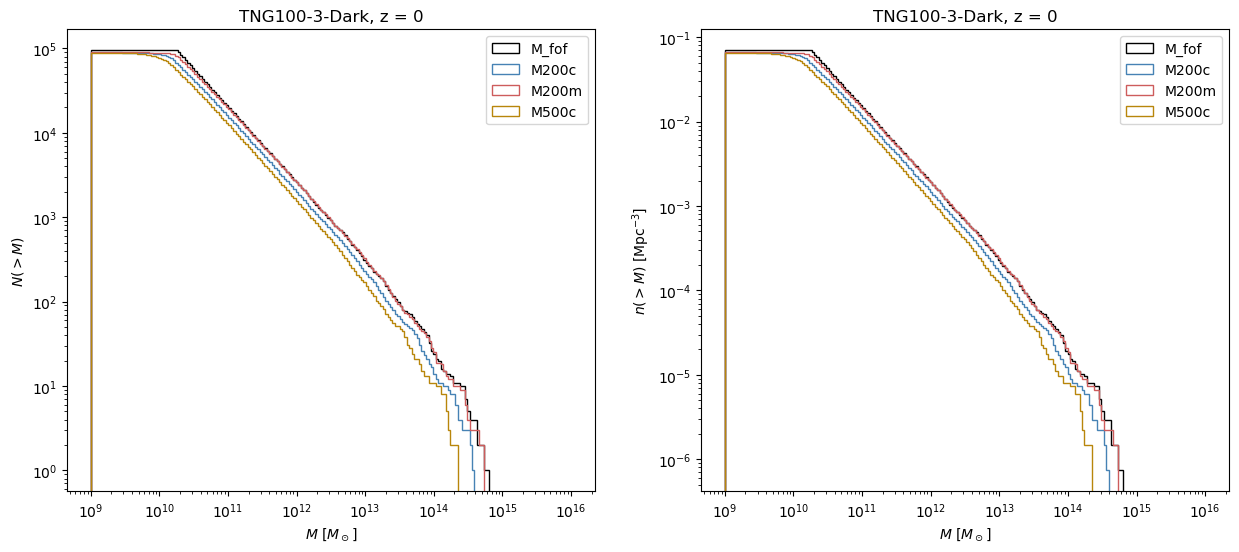

In [5]:
bins = np.logspace(9, 16, 200)   # Msun, same log bins for all the cumulative plots

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for name, M in masses.items():
    axes[0].hist(M, bins=bins, cumulative=-1, histtype='step', color=colors[name], label=name)
    axes[1].hist(M, bins=bins, weights=np.ones(len(M)) / volume, cumulative=-1, histtype='step', color=colors[name], label=name)

axes[0].set(ylabel=r'$N(>M)$')
axes[1].set(ylabel=r'$n(>M)$ [Mpc$^{-3}$]')
for ax in axes:
    ax.set(xscale='log', yscale='log', xlabel=r'$M$ [$M_\odot$]', title='TNG100-3-Dark, z = 0')
    ax.legend()
plt.show()

In [6]:
for name, M in masses.items():
    N_12 = np.sum(M > 1e12)
    n_12 = N_12 / volume
    print(f'{name}: N(>1e12) = {N_12}, n(>1e12) = {n_12:.2e} Mpc^-3')

#"Milky-Way like" = haloes around 1e12, so here I count haloes within +-0.1 dex of the given mass
def N_around(M, M0, dex=0.1):
    return np.sum((M > M0 * 10**-dex) & (M < M0 * 10**dex))

print()
for name, M in masses.items():
    N11, N12, N13, N14 = [N_around(M, M0) for M0 in [1e11, 1e12, 1e13, 1e14]]
    ratio_12_14 = N12 / N14 if N14 > 0 else np.inf
    ratio_13_11 = N13 / N11
    print(f'{name}: N(1e11, 1e12, 1e13, 1e14) = {N11}, {N12}, {N13}, {N14}  ->  '
          f'MW-like / 1e14 = {ratio_12_14:.0f},  1e13 / 1e11 = {ratio_13_11:.4f}')

M_min = group_len.min() * dm_mass
print(f'\nsmallest group: {group_len.min()} particles -> M_min = {M_min:.2e} Msun')

M_fof: N(>1e12) = 2532, n(>1e12) = 1.87e-03 Mpc^-3
M200c: N(>1e12) = 1969, n(>1e12) = 1.45e-03 Mpc^-3
M200m: N(>1e12) = 2531, n(>1e12) = 1.86e-03 Mpc^-3
M500c: N(>1e12) = 1535, n(>1e12) = 1.13e-03 Mpc^-3

M_fof: N(1e11, 1e12, 1e13, 1e14) = 8203, 1039, 150, 22  ->  MW-like / 1e14 = 47,  1e13 / 1e11 = 0.0183
M200c: N(1e11, 1e12, 1e13, 1e14) = 6189, 817, 98, 10  ->  MW-like / 1e14 = 82,  1e13 / 1e11 = 0.0158
M200m: N(1e11, 1e12, 1e13, 1e14) = 7693, 1026, 146, 20  ->  MW-like / 1e14 = 51,  1e13 / 1e11 = 0.0190
M500c: N(1e11, 1e12, 1e13, 1e14) = 5073, 644, 76, 4  ->  MW-like / 1e14 = 161,  1e13 / 1e11 = 0.0150

smallest group: 32 particles -> M_min = 1.81e+10 Msun


### 1.1 discussion

For all definitions, $N(>M)$ goes roughly like a power law at low mass and then drops exponentially above $\sim10^{13-14}\,M_\odot$. There are a few thousand haloes above $10^{12}\,M_\odot$ in TNG100-3-Dark, i.e. $n(>10^{12}) \sim 10^{-3}$ Mpc$^{-3}$: in a box of ~110 Mpc this means roughly one MW-like halo every ~10 Mpc. The number depends on the mass definition: $M_{fof} > M_{200m} > M_{200c} > M_{500c}$ for the same object, because the lower the overdensity threshold, the larger the radius and so the mass included. So the M500c curve is shifted to the left and gives the smallest count, the FoF and M200m are the largest.

MW-like haloes are a few hundred times more numerous than $10^{14}\,M_\odot$ haloes (and there are only a handful of $10^{14}$ haloes in this box, so the number is noisy). $10^{13}\,M_\odot$ haloes are about 1–2% as numerous as $10^{11}\,M_\odot$ haloes.

The minimum halo mass is set by the resolution: the FoF algorithm only keeps groups with at least 32 particles, so $M_{min} = 32 \times 5.7\times10^8 \approx 1.8\times10^{10}\,M_\odot$. Below this the curves flatten (the mass function is incomplete). The SO masses (M200c, M500c) can go below this value because they only take part of the FoF group, but haloes with few tens of particles are not really resolved anyway, I would trust the curves only above a few $10^{10}-10^{11}\,M_\odot$.

### 1.2

TNG100-3-Dark vs TNG300-3-Dark at z=0. For the differential mass function I use bins of 0.1 dex and take the median mass of the haloes in the bin as $x$, as suggested.

TNG100-3-Dark: box = 110.7 Mpc, particle mass = 5.67e+08 Msun, M_min = 1.81e+10 Msun
TNG300-3-Dark: box = 302.6 Mpc, particle mass = 4.47e+09 Msun, M_min = 1.43e+11 Msun


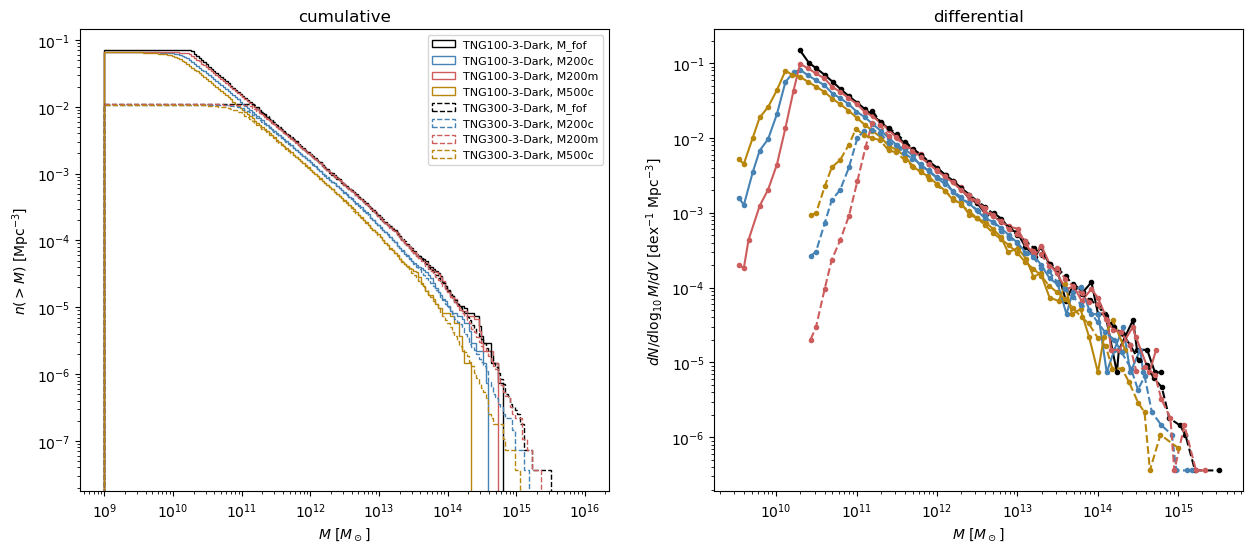

In [7]:
sims = {'TNG100-3-Dark': '/home/tnguser/sims.TNG/TNG100-3-Dark/output',
        'TNG300-3-Dark': '/home/tnguser/sims.TNG/TNG300-3-Dark/output'}
lines = {'TNG100-3-Dark': '-', 'TNG300-3-Dark': '--'}

mf = {}
for sim, path in sims.items():
    masses_sim, volume_sim, group_len_sim, header_sim = load_masses(path, 99)
    mf[sim] = (masses_sim, volume_sim)
    m_part = header_sim['MassTable'][1] * 1e10 / header_sim['HubbleParam']
    print(f'{sim}: box = {volume_sim**(1/3):.1f} Mpc, particle mass = {m_part:.2e} Msun, '
          f'M_min = {group_len_sim.min() * m_part:.2e} Msun')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for sim, (masses_sim, volume_sim) in mf.items():
    for name, M in masses_sim.items():
        axes[0].hist(M, bins=bins, weights=np.ones(len(M)) / volume_sim, cumulative=-1, histtype='step',
                     color=colors[name], ls=lines[sim], label=f'{sim}, {name}')
        M_med, dndlogM, dndM_sim = differential_mf(M, volume_sim)
        axes[1].plot(M_med, dndlogM, color=colors[name], ls=lines[sim], marker='.')

axes[0].set(ylabel=r'$n(>M)$ [Mpc$^{-3}$]', title='cumulative')
axes[1].set(ylabel=r'$dN/d\log_{10}M/dV$ [dex$^{-1}$ Mpc$^{-3}$]', title='differential')
for ax in axes:
    ax.set(xscale='log', yscale='log', xlabel=r'$M$ [$M_\odot$]')
axes[0].legend(fontsize=8)
plt.show()

In [8]:
for sim, (masses_sim, volume_sim) in mf.items():
    for name, M in masses_sim.items():
        N_14 = np.sum(M > 1e14)
        n_14 = N_14 / volume_sim
        print(f'{sim}, {name}: N(>1e14) = {N_14}, n(>1e14) = {n_14:.2e} Mpc^-3')

TNG100-3-Dark, M_fof: N(>1e14) = 24, n(>1e14) = 1.77e-05 Mpc^-3
TNG100-3-Dark, M200c: N(>1e14) = 14, n(>1e14) = 1.03e-05 Mpc^-3
TNG100-3-Dark, M200m: N(>1e14) = 24, n(>1e14) = 1.77e-05 Mpc^-3
TNG100-3-Dark, M500c: N(>1e14) = 11, n(>1e14) = 8.10e-06 Mpc^-3
TNG300-3-Dark, M_fof: N(>1e14) = 493, n(>1e14) = 1.78e-05 Mpc^-3
TNG300-3-Dark, M200c: N(>1e14) = 281, n(>1e14) = 1.01e-05 Mpc^-3
TNG300-3-Dark, M200m: N(>1e14) = 462, n(>1e14) = 1.67e-05 Mpc^-3
TNG300-3-Dark, M500c: N(>1e14) = 157, n(>1e14) = 5.66e-06 Mpc^-3


### 1.2 discussion

In the mass range where both boxes are resolved, the two simulations agree well, both in the cumulative and in the differential mass function, as they should (same cosmology, same code). The differences are at the two ends: TNG300-3-Dark has an ~8 times heavier particle, so its mass function turns over at higher mass (~$10^{11}\,M_\odot$ instead of ~$2\times10^{10}$); TNG100-3-Dark has a ~20 times smaller volume, so it runs out of haloes at the high mass end and the last bins are very noisy (few haloes per bin).

Above $10^{14}\,M_\odot$ there are only of order ten haloes in TNG100-3-Dark but a few hundred in TNG300-3-Dark (see the numbers above), i.e. a typical number density of $n(>10^{14}) \sim 10^{-5}$ Mpc$^{-3}$ in both, so roughly one cluster per $(45\,\mathrm{Mpc})^3$. To sample clusters one needs big boxes, to sample dwarfs one needs high resolution.

### 1.3 [Optional]

Illustris has 136 snapshots, z = 0 is snap 135. I compare M_fof and M200c and print the cosmological parameters of the two runs from the headers.

TNG100-3-Dark: Omega_m = 0.3089, Omega_L = 0.6911, h = 0.6774, box = 110.7 Mpc
Illustris-3-Dark: Omega_m = 0.2726, Omega_L = 0.7274, h = 0.7040, box = 106.5 Mpc


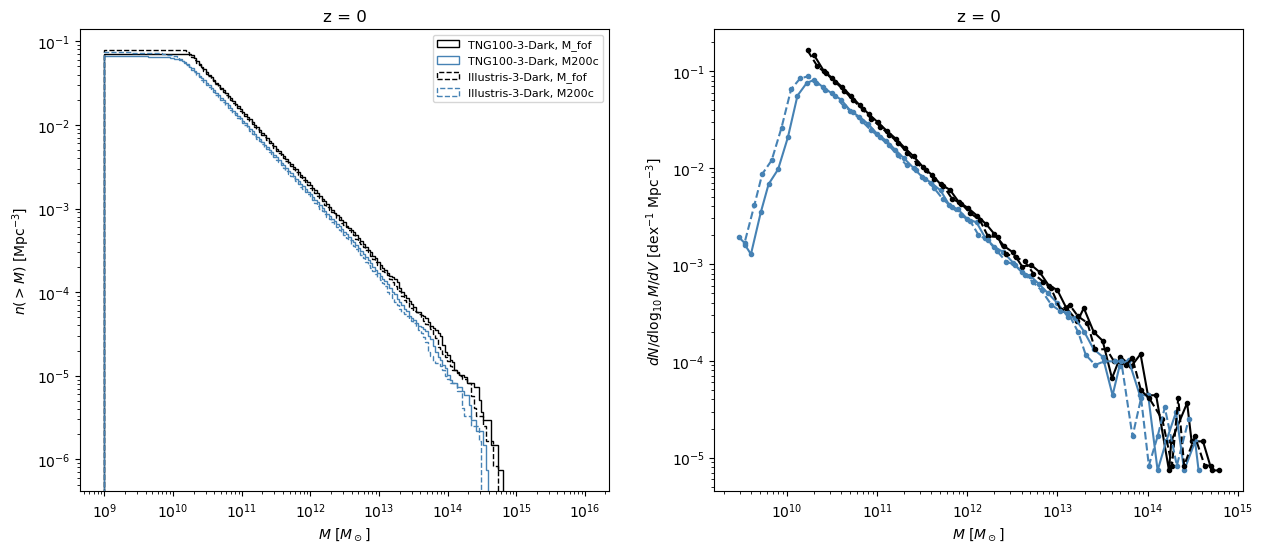

In [9]:
basePath_ill = '/home/tnguser/sims.illustris/Illustris-3-Dark/output'
runs = {'TNG100-3-Dark': (sims['TNG100-3-Dark'], 99), 'Illustris-3-Dark': (basePath_ill, 135)}
lines_ill = {'TNG100-3-Dark': '-', 'Illustris-3-Dark': '--'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for run, (path, snap_run) in runs.items():
    masses_run, volume_run, _, header_run = load_masses(path, snap_run)
    print(f"{run}: Omega_m = {header_run['Omega0']:.4f}, Omega_L = {header_run['OmegaLambda']:.4f}, "
          f"h = {header_run['HubbleParam']:.4f}, box = {volume_run**(1/3):.1f} Mpc")
    for name in ['M_fof', 'M200c']:
        M = masses_run[name]
        axes[0].hist(M, bins=bins, weights=np.ones(len(M)) / volume_run, cumulative=-1, histtype='step',
                     color=colors[name], ls=lines_ill[run], label=f'{run}, {name}')
        M_med, dndlogM, dndM_sim = differential_mf(M, volume_run)
        axes[1].plot(M_med, dndlogM, color=colors[name], ls=lines_ill[run], marker='.')

axes[0].set(ylabel=r'$n(>M)$ [Mpc$^{-3}$]')
axes[1].set(ylabel=r'$dN/d\log_{10}M/dV$ [dex$^{-1}$ Mpc$^{-3}$]')
for ax in axes:
    ax.set(xscale='log', yscale='log', xlabel=r'$M$ [$M_\odot$]', title='z = 0')
axes[0].legend(fontsize=8)
plt.show()

### 1.3 discussion

The two mass functions have the same shape, but TNG100-3-Dark has somewhat more haloes at fixed mass, and the difference grows towards the high mass end. Both runs have the same number of particles in a 75 Mpc/h box, so the resolution is basically the same, the difference comes from the cosmology: Illustris uses WMAP9 ($\Omega_m = 0.2726$, $\sigma_8 = 0.809$, $h = 0.704$), TNG uses Planck 2015 ($\Omega_m = 0.3089$, $\sigma_8 = 0.8159$, $h = 0.6774$). More matter and slightly larger fluctuations give more massive haloes, and since the high mass end is exponentially sensitive to $\sigma(M)$ the effect is biggest there. (The box in Mpc is also slightly different because of $h$.)

### 1.4

From the TNG docs: snaps 99, 50, 33, 21 are z = 0, 1, 2, 4. Volume stays the comoving one, so $n$ is a comoving number density.

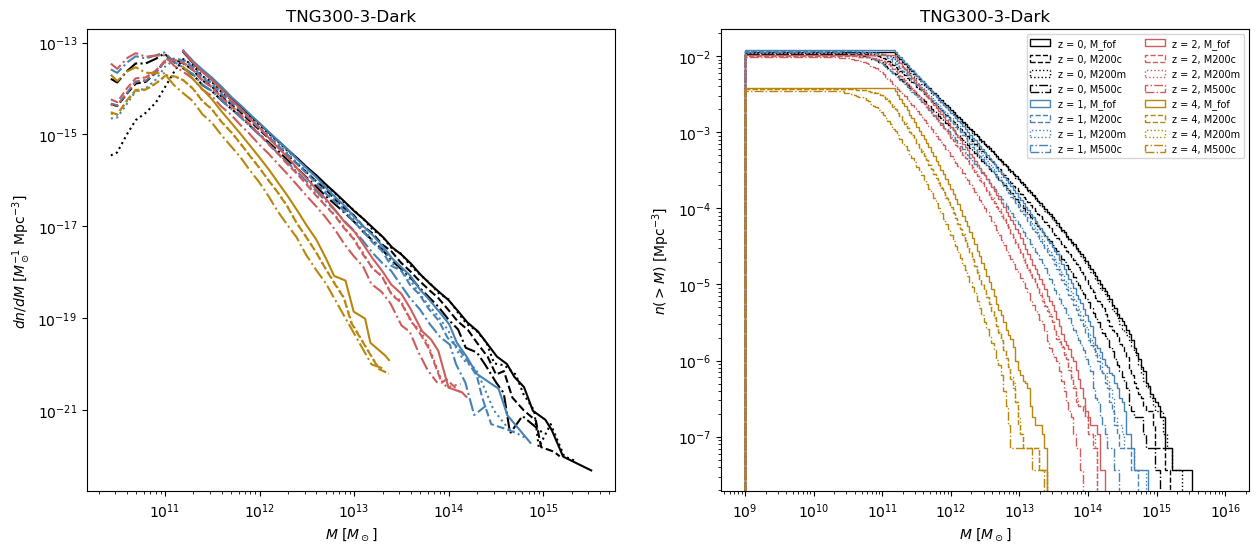

In [10]:
snaps_14 = {0: 99, 1: 50, 2: 33, 4: 21}
z_colors = {0: 'black', 1: 'steelblue', 2: 'indianred', 4: 'darkgoldenrod'}
mass_lines = {'M_fof': '-', 'M200c': '--', 'M200m': ':', 'M500c': '-.'}

mf_z = {}
for z, snap_z in snaps_14.items():
    mf_z[z] = load_masses(sims['TNG300-3-Dark'], snap_z)[:2]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for z, (masses_z, volume_z) in mf_z.items():
    for name, M in masses_z.items():
        M_med, dndlogM, dndM_sim = differential_mf(M, volume_z)
        label = f'z = {z}, {name}'
        axes[0].plot(M_med, dndM_sim, color=z_colors[z], ls=mass_lines[name], label=label)
        axes[1].hist(M, bins=bins, weights=np.ones(len(M)) / volume_z, cumulative=-1, histtype='step',
                     color=z_colors[z], ls=mass_lines[name], label=label)

axes[0].set(ylabel=r'$dn/dM$ [$M_\odot^{-1}$ Mpc$^{-3}$]')
axes[1].set(ylabel=r'$n(>M)$ [Mpc$^{-3}$]')
for ax in axes:
    ax.set(xscale='log', yscale='log', xlabel=r'$M$ [$M_\odot$]', title='TNG300-3-Dark')
axes[1].legend(fontsize=7, ncol=2)
plt.show()

In [11]:
for name in fields:
    (masses_0, volume_0), (masses_2, volume_2) = mf_z[0], mf_z[2]
    N_14_z0 = np.sum(masses_0[name] > 1e14)
    N_14_z2 = np.sum(masses_2[name] > 1e14)
    n_14_z0 = N_14_z0 / volume_0
    n_14_z2 = N_14_z2 / volume_2
    if N_14_z2 > 0:
        print(f'{name}: n(>1e14) z=0: {n_14_z0:.2e} ({N_14_z0}), z=2: {n_14_z2:.2e} ({N_14_z2}), '
              f'ratio: {n_14_z0 / n_14_z2:.0f}')
    else:
        #no halo at z=2: only an upper limit of 1 halo per box
        print(f'{name}: n(>1e14) z=0: {n_14_z0:.2e} ({N_14_z0}), z=2: < {1 / volume_2:.2e} (0), '
              f'ratio: > {n_14_z0 * volume_2:.0f}')

M_fof: n(>1e14) z=0: 1.78e-05 (493), z=2: 1.80e-07 (5), ratio: 99
M200c: n(>1e14) z=0: 1.01e-05 (281), z=2: 1.08e-07 (3), ratio: 94
M200m: n(>1e14) z=0: 1.67e-05 (462), z=2: 1.08e-07 (3), ratio: 154
M500c: n(>1e14) z=0: 5.66e-06 (157), z=2: < 3.61e-08 (0), ratio: > 157


### 1.4 discussion

At low masses the mass function changes little with redshift (within a factor of a few between z=0 and z=2), but the exponential cut-off moves to lower masses going to higher z: at z=4 there are basically no haloes above a few $10^{13}\,M_\odot$. Haloes grow hierarchically, so the most massive objects are the last to form. $10^{14}\,M_\odot$ haloes are of order a hundred times rarer at z=2 than at z=0 (only a few of them, or none depending on the mass definition, are in the whole TNG300 box at z=2, so the ratio above is only a rough number / a lower limit). The ordering of the mass definitions is the same at all z.

## 2. Build your own Python Cosmological Calculator (Part III)

Formulas used (k in 1/Mpc, R in Mpc, M in Msun):

- Transfer function (BBKS): $T(q) = \dfrac{\ln(1+2.34q)}{2.34q}\left[1 + 3.89q + (16.1q)^2 + (5.46q)^3 + (6.71q)^4\right]^{-1/4}$, with $q = \dfrac{k}{\Omega_m h^2\,\mathrm{Mpc}^{-1}}$ (i.e. $k/\Gamma$ with $\Gamma = \Omega_m h$ and $k$ in h/Mpc)
- $P(k,z) = A\,k^{n_s}\,T^2(k)\,D_+^2(z)$, with $D_+$ the growth factor of Problem Sheet 3 ($D_+(0)=1$) and $A$ fixed so that $\sigma(R = 8\,h^{-1}\mathrm{Mpc}, z=0) = \sigma_8$
- $\sigma^2(R) = \dfrac{1}{2\pi^2}\displaystyle\int_0^\infty k^2 P(k)\,W^2(kR)\,dk$, with the top-hat window $W(x) = \dfrac{3(\sin x - x\cos x)}{x^3}$
- $M(R) = \dfrac{4\pi}{3}\bar\rho_m R^3$, with $\bar\rho_m = \Omega_m\rho_{crit,0} = \Omega_m \times 2.775\times10^{11}h^2\,M_\odot/\mathrm{Mpc}^3$

The integral is done on a log grid in k from $10^{-5}$ to $10^3$ Mpc$^{-1}$ (as $\int k^3 P W^2\,d\ln k$).

In [12]:
#growth factor from Problem Sheet 3
def E(z, Om, Or, OL):
    Ok = 1 - Om - Or - OL
    return np.sqrt(Or*(1+z)**4 + Om*(1+z)**3 + Ok*(1+z)**2 + OL)

def g_carroll(Om, OL):
    return 2.5*Om / (Om**(4/7) - OL + (1+Om/2)*(1+OL/70))

def D_plus(z, Om, Or, OL):
    Omz = Om*(1+z)**3 / E(z, Om, Or, OL)**2
    OLz = OL / E(z, Om, Or, OL)**2
    return g_carroll(Omz, OLz) / g_carroll(Om, OL) / (1+z)

In [13]:
k_int = np.logspace(-5, 3, 4000)    # 1/Mpc, integration grid for sigma

def T_BBKS(k, cosmo):
    #BBKS transfer function, k in 1/Mpc
    q = k / (cosmo['Om'] * cosmo['h']**2)
    return np.log(1 + 2.34*q) / (2.34*q) * (1 + 3.89*q + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4)**-0.25

def W_tophat(x):
    #Fourier transform of the spherical top-hat window, x = kR
    return 3 * (np.sin(x) - x*np.cos(x)) / x**3

def sigma2_unnorm(R, cosmo):
    #sigma^2(R) at z = 0 for A = 1, R can be an array
    R = np.atleast_1d(R)[:, None]
    integrand = k_int**3 * k_int**cosmo['ns'] * T_BBKS(k_int, cosmo)**2 * W_tophat(k_int * R)**2
    return trapezoid(integrand, np.log(k_int), axis=1) / (2*np.pi**2)

def normalisation(cosmo):
    #amplitude A such that sigma(8 Mpc/h, z=0) = sigma8
    return cosmo['sigma8']**2 / sigma2_unnorm(8 / cosmo['h'], cosmo)[0]

def P_lin(k, z, cosmo):
    #linear P(k, z) [Mpc^3], k in 1/Mpc, normalised to cosmo['sigma8'] at z = 0
    D = D_plus(z, cosmo['Om'], cosmo['Or'], cosmo['OL'])
    return normalisation(cosmo) * k**cosmo['ns'] * T_BBKS(k, cosmo)**2 * D**2

def sigma_R(R, z, cosmo):
    #rms of the linear density field smoothed with a top-hat of radius R [Mpc]
    D = D_plus(z, cosmo['Om'], cosmo['Or'], cosmo['OL'])
    s = np.sqrt(normalisation(cosmo) * sigma2_unnorm(R, cosmo)) * D
    return s if np.ndim(R) else s[0]

def rho_mean(cosmo):
    #mean comoving matter density today [Msun/Mpc^3]
    return cosmo['Om'] * 2.775e11 * cosmo['h']**2

def R_of_M(M, cosmo):
    #Lagrangian radius [Mpc] of a mass M [Msun]
    return (3 * M / (4*np.pi * rho_mean(cosmo)))**(1/3)

def sigma_M(M, z, cosmo):
    #sigma(M, z), M in Msun (array)
    return sigma_R(R_of_M(M, cosmo), z, cosmo)

In [14]:
#TNG / Planck 2015 cosmology
tng = dict(Om=0.3089, Or=0, OL=0.6911, h=0.6774, ns=0.9667, sigma8=0.8159)

print('sigma(R = 8/h Mpc, z=0) =', sigma_R(8 / tng['h'], 0, tng), ' vs sigma8 =', tng['sigma8'])
print('D+(z = 1, 4) =', D_plus(np.array([1, 4]), tng['Om'], tng['Or'], tng['OL']))

sigma(R = 8/h Mpc, z=0) = 0.8159  vs sigma8 = 0.8159
D+(z = 1, 4) = [0.60972475 0.25449084]


### 2.1

P(k, z) vs. k in LCDM (TNG cosmology) at z = 0, 1, 4.

z = 0: peak at k = 0.014 1/Mpc, P_max = 4.624e+04 Mpc^3
z = 1: peak at k = 0.014 1/Mpc, P_max = 1.719e+04 Mpc^3
z = 4: peak at k = 0.014 1/Mpc, P_max = 2.995e+03 Mpc^3


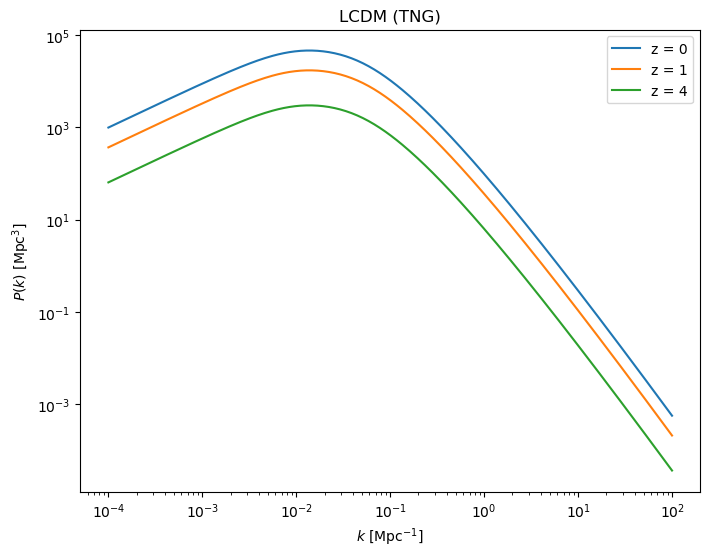

In [15]:
k = np.logspace(-4, 2, 300)    # 1/Mpc

fig, ax = plt.subplots(figsize=(8, 6))
for z in [0, 1, 4]:
    P = P_lin(k, z, tng)
    ax.plot(k, P, label=f'z = {z}')
    print(f'z = {z}: peak at k = {k[P.argmax()]:.3f} 1/Mpc, P_max = {P.max():.3e} Mpc^3')
ax.set(xscale='log', yscale='log', xlabel=r'$k$ [Mpc$^{-1}$]', ylabel=r'$P(k)$ [Mpc$^3$]', title='LCDM (TNG)')
ax.legend()
plt.show()

### 2.1 discussion

The shape is the same at all redshifts: $P \propto k^{n_s}$ on large scales (small k), a turnover at $k \sim 0.015$ Mpc$^{-1}$ which is set by the horizon size at matter-radiation equality, and $P \propto k^{n_s-4}$ (times a log) on small scales, where the modes entered the horizon during radiation domination and their growth was suppressed. In linear theory all modes grow by the same factor, so the curves are just shifted vertically by $D_+^2(z)$: $D_+(1)^2 \approx 0.37$, $D_+(4)^2 \approx 0.065$.

### 2.2

Same three models as in Problem Sheet 2 (h = 0.7), same ns and sigma8 for all of them.

EdS (Om=1, OL=0)            : peak at k = 0.047 1/Mpc, P_max = 9.472e+03 Mpc^3
Low-density (Om=0.3, OL=0)  : peak at k = 0.014 1/Mpc, P_max = 4.168e+04 Mpc^3
LCDM (Om=0.3, OL=0.7)       : peak at k = 0.014 1/Mpc, P_max = 4.168e+04 Mpc^3


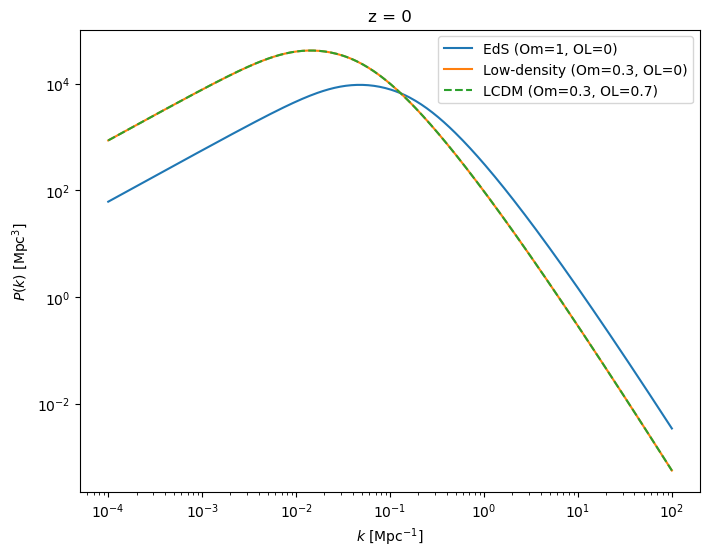

In [16]:
models = {
    'EdS (Om=1, OL=0)':           dict(tng, Om=1.0, OL=0.0, h=0.7),
    'Low-density (Om=0.3, OL=0)': dict(tng, Om=0.3, OL=0.0, h=0.7),
    'LCDM (Om=0.3, OL=0.7)':      dict(tng, Om=0.3, OL=0.7, h=0.7),
}

fig, ax = plt.subplots(figsize=(8, 6))
for (name, cosmo), ls in zip(models.items(), ['-', '-', '--']):
    P = P_lin(k, 0, cosmo)
    ax.plot(k, P, ls=ls, label=name)
    print(f'{name:28s}: peak at k = {k[P.argmax()]:.3f} 1/Mpc, P_max = {P.max():.3e} Mpc^3')
ax.set(xscale='log', yscale='log', xlabel=r'$k$ [Mpc$^{-1}$]', ylabel=r'$P(k)$ [Mpc$^3$]', title='z = 0')
ax.legend()
plt.show()

### 2.2 discussion

The low-density and the LCDM curves lie exactly on top of each other (dashed on solid): at z=0 the transfer function only depends on $\Omega_m h$, and both are normalised to the same $\sigma_8$ today, so $\Omega_\Lambda$ only enters through $D_+$, which is 1 at z=0 by construction. They would differ at z>0, or if they were normalised at early times instead of today. EdS has a larger $\Omega_m h$, so matter-radiation equality happens earlier, the turnover moves to smaller scales (larger k, ~0.05 vs ~0.014 Mpc$^{-1}$), and with the same $\sigma_8$ it has more power on small scales and less on large scales.

### 2.3

LCDM (TNG cosmology) with sigma8 = 0.7, 0.8, 0.9.

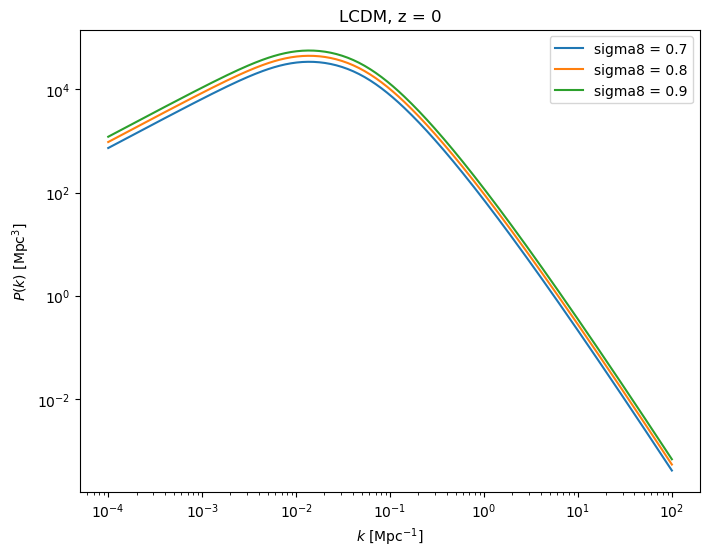

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for s8 in [0.7, 0.8, 0.9]:
    ax.plot(k, P_lin(k, 0, dict(tng, sigma8=s8)), label=f'sigma8 = {s8}')
ax.set(xscale='log', yscale='log', xlabel=r'$k$ [Mpc$^{-1}$]', ylabel=r'$P(k)$ [Mpc$^3$]', title='LCDM, z = 0')
ax.legend()
plt.show()

### 2.3 discussion

$\sigma_8$ is only the amplitude: $P \propto \sigma_8^2$, so the three curves have the same shape and are shifted vertically, going from 0.7 to 0.9 gives $(0.9/0.7)^2 \approx 1.65$ times more power at all k.

### 2.4

sigma(M, z) vs. M at z = 0, 1, 4 in LCDM (TNG cosmology).

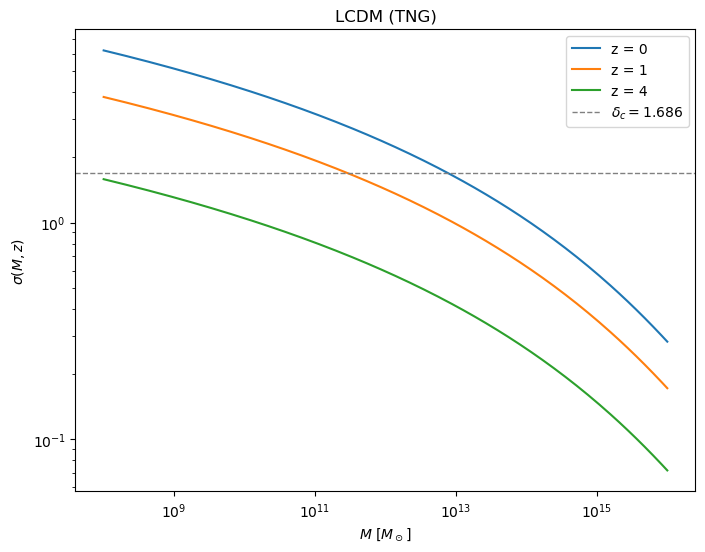

z = 0: sigma(M*) = delta_c at M* = 7.88e+12 Msun
z = 1: sigma(M*) = delta_c at M* = 2.98e+11 Msun
z = 4: sigma(M*) = delta_c at M* = 1.00e+08 Msun


In [18]:
M_grid = np.logspace(8, 16, 200)    # Msun

fig, ax = plt.subplots(figsize=(8, 6))
for z in [0, 1, 4]:
    ax.plot(M_grid, sigma_M(M_grid, z, tng), label=f'z = {z}')
ax.axhline(1.686, color='gray', ls='--', lw=1, label=r'$\delta_c = 1.686$')
ax.set(xscale='log', yscale='log', xlabel=r'$M$ [$M_\odot$]', ylabel=r'$\sigma(M, z)$', title='LCDM (TNG)')
ax.legend()
plt.show()

for z in [0, 1, 4]:
    M_star = np.interp(0, np.log(sigma_M(M_grid, z, tng) / 1.686)[::-1], M_grid[::-1])
    print(f'z = {z}: sigma(M*) = delta_c at M* = {M_star:.2e} Msun')

### 2.4 discussion

$\sigma(M)$ decreases with mass: small scales have larger fluctuations, so in CDM small objects collapse first (hierarchical growth). At low masses the curve becomes very flat (the $k^{-3}$ tail of P(k) gives only a logarithmic growth of $\sigma$), at high mass it drops steeply. With redshift the curve just scales with $D_+(z)$. The mass where $\sigma = \delta_c$ (typical collapsing mass $M_*$) is ~$10^{13}\,M_\odot$ today but goes down by orders of magnitude at z=1 and z=4: the same halo mass is a much rarer peak at high z.

### 2.5

sigma(M) at z = 0 in flat LCDM with $\Omega_m$ = 0.2, 0.3, 0.4 ($\Omega_\Lambda = 1 - \Omega_m$), all the other parameters as TNG (same $\sigma_8$).

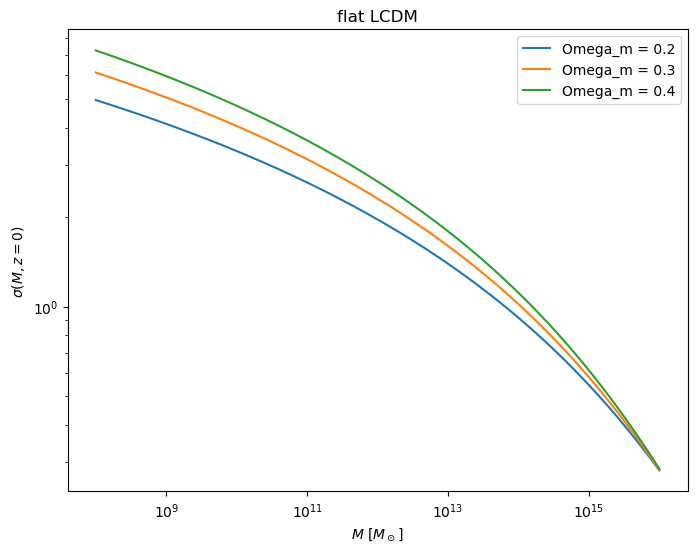

Omega_m = 0.2: sigma(1e10, 1e12, 1e15 Msun) = [3.34 1.96 0.54] , R(1e12 Msun) = 2.11 Mpc
Omega_m = 0.3: sigma(1e10, 1e12, 1e15 Msun) = [4.05 2.31 0.58] , R(1e12 Msun) = 1.84 Mpc
Omega_m = 0.4: sigma(1e10, 1e12, 1e15 Msun) = [4.74 2.63 0.61] , R(1e12 Msun) = 1.67 Mpc


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for Om in [0.2, 0.3, 0.4]:
    ax.plot(M_grid, sigma_M(M_grid, 0, dict(tng, Om=Om, OL=1 - Om)), label=f'Omega_m = {Om}')
ax.set(xscale='log', yscale='log', xlabel=r'$M$ [$M_\odot$]', ylabel=r'$\sigma(M, z=0)$', title='flat LCDM')
ax.legend()
plt.show()

for Om in [0.2, 0.3, 0.4]:
    cosmo = dict(tng, Om=Om, OL=1 - Om)
    print(f'Omega_m = {Om}: sigma(1e10, 1e12, 1e15 Msun) =', np.round(sigma_M(np.array([1e10, 1e12, 1e15]), 0, cosmo), 2),
          f', R(1e12 Msun) = {R_of_M(1e12, cosmo):.2f} Mpc')

### 2.5 discussion

Larger $\Omega_m$ gives larger $\sigma$ at fixed mass, especially at low masses. Two effects: (1) with the same mass, higher $\bar\rho_m$ means a smaller Lagrangian radius $R(M)$, so we look at smaller scales where $\sigma$ is larger; (2) larger $\Omega_m h$ moves the turnover of P(k) to larger k, so with the same $\sigma_8$ there is more small-scale power. At the high mass end the curves get closer, since all of them are pinned to the same $\sigma_8$ at $8\,h^{-1}$Mpc (~$10^{14}\,M_\odot$).

## 3. Analytical vs. Numerical formulas for the dark-matter halo mass functions

### 3.1

Formulas used (from the lecture / input notebook), with $\delta_c = 1.686$:

- $\dfrac{dn}{dM} = f(\sigma)\,\dfrac{\bar\rho_m}{M}\,\dfrac{d\ln\sigma^{-1}}{dM}$, the derivative done numerically with `np.gradient`
- Press & Schechter: $f(\sigma) = \sqrt{\dfrac{2}{\pi}}\,\dfrac{\delta_c}{\sigma}\exp\left(-\dfrac{\delta_c^2}{2\sigma^2}\right)$
- Sheth & Tormen: $f(\sigma) = A\sqrt{\dfrac{2a}{\pi}}\left[1 + \left(\dfrac{\sigma^2}{a\delta_c^2}\right)^p\right]\dfrac{\delta_c}{\sigma}\exp\left(-\dfrac{a\delta_c^2}{2\sigma^2}\right)$, with $A = 0.3222$, $a = 0.707$, $p = 0.3$
- Tinker+08: $f(\sigma) = A\left[\left(\dfrac{\sigma}{b}\right)^{-a} + 1\right]\exp\left(-\dfrac{c}{\sigma^2}\right)$, with $A, a, b, c$ from Table 2 of Tinker+08 (interpolated in $\log\Delta$) and the redshift evolution $A(z) = A_0(1+z)^{-0.14}$, $a(z) = a_0(1+z)^{-0.06}$, $b(z) = b_0(1+z)^{-\alpha}$, $\log\alpha = -\left[0.75/\log(\Delta/75)\right]^{1.2}$

Tinker's $\Delta$ is w.r.t. the mean matter density, so for M200c I use $\Delta = 200/\Omega_m(z)$, i.e. $\Delta \approx 647$ at z=0.

In [20]:
delta_c = 1.686

#Tinker+08 Table 2: Delta, A, a, b, c
tinker_table = np.array([
    [200,   300,   400,   600,   800,   1200,  1600,  2400,  3200],
    [0.186, 0.200, 0.212, 0.218, 0.248, 0.255, 0.260, 0.260, 0.260],
    [1.47,  1.52,  1.56,  1.61,  1.87,  2.13,  2.30,  2.53,  2.66],
    [2.57,  2.25,  2.05,  1.87,  1.59,  1.51,  1.46,  1.44,  1.41],
    [1.19,  1.27,  1.34,  1.45,  1.58,  1.80,  1.97,  2.24,  2.44]])

def f_PS(sigma):
    return np.sqrt(2/np.pi) * delta_c/sigma * np.exp(-delta_c**2 / (2*sigma**2))

def f_ST(sigma):
    A, a, p = 0.3222, 0.707, 0.3
    return A * np.sqrt(2*a/np.pi) * (1 + (sigma**2 / (a*delta_c**2))**p) * delta_c/sigma \
             * np.exp(-a*delta_c**2 / (2*sigma**2))

def f_Tinker(sigma, z, Delta):
    #Tinker+08, Delta w.r.t. the mean matter density
    A0, a0, b0, c = [np.interp(np.log10(Delta), np.log10(tinker_table[0]), row) for row in tinker_table[1:]]
    alpha = 10**(-(0.75 / np.log10(Delta / 75))**1.2)
    A = A0 * (1+z)**-0.14
    a = a0 * (1+z)**-0.06
    b = b0 * (1+z)**-alpha
    return A * ((sigma/b)**-a + 1) * np.exp(-c / sigma**2)

def dndM(M, z, cosmo, f):
    #dn/dM [1/Msun/Mpc^3], f is a function of sigma only
    s = sigma_M(M, z, cosmo)
    return f(s) * rho_mean(cosmo) / M * np.gradient(np.log(1/s), M)

Delta = 647 (w.r.t. the mean density)


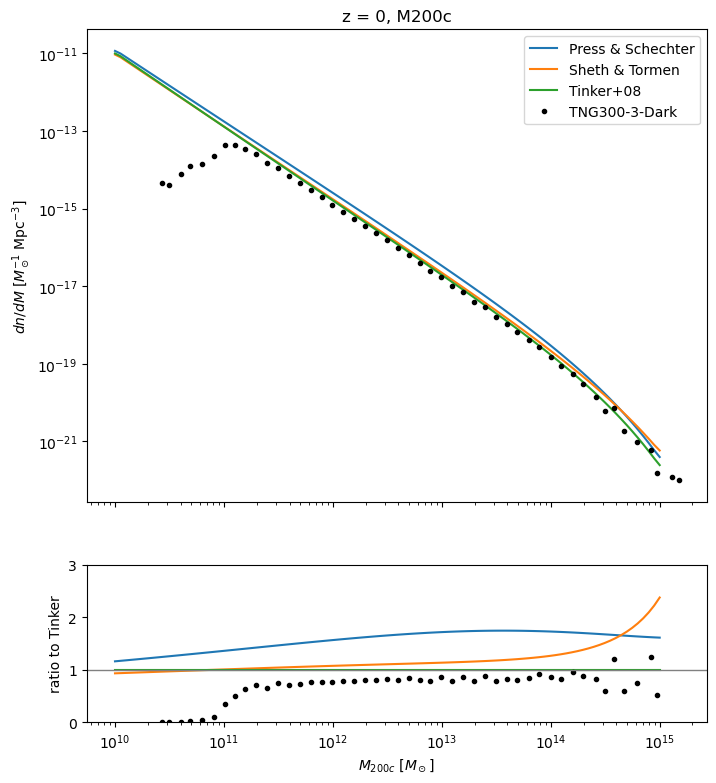

In [21]:
M_hmf = np.logspace(10, 15, 100)
Delta = 200 / tng['Om']      # M200c -> 200 rho_crit = 200/Om rho_mean at z = 0
print(f'Delta = {Delta:.0f} (w.r.t. the mean density)')

mf_formulas = {
    'Press & Schechter': dndM(M_hmf, 0, tng, f_PS),
    'Sheth & Tormen':    dndM(M_hmf, 0, tng, f_ST),
    'Tinker+08':         dndM(M_hmf, 0, tng, lambda s: f_Tinker(s, 0, Delta)),
}

fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
for name, mf_M in mf_formulas.items():
    axes[0].plot(M_hmf, mf_M, label=name)
    axes[1].plot(M_hmf, mf_M / mf_formulas['Tinker+08'], label=name)

#optional: TNG300-3-Dark M200c from 1.2
masses_300, volume_300 = mf['TNG300-3-Dark']
M_med, dndlogM, dndM_sim = differential_mf(masses_300['M200c'], volume_300)
axes[0].plot(M_med, dndM_sim, 'o', color='black', ms=3, label='TNG300-3-Dark')
in_range = (M_med > M_hmf[0]) & (M_med < M_hmf[-1])
axes[1].plot(M_med[in_range], dndM_sim[in_range] / np.interp(np.log10(M_med[in_range]), np.log10(M_hmf),
             mf_formulas['Tinker+08']), 'o', color='black', ms=3)

axes[0].set(xscale='log', yscale='log', ylabel=r'$dn/dM$ [$M_\odot^{-1}$ Mpc$^{-3}$]', title='z = 0, M200c')
axes[0].legend()
axes[1].axhline(1, color='gray', lw=1)
axes[1].set(xscale='log', xlabel=r'$M_{200c}$ [$M_\odot$]', ylabel='ratio to Tinker', ylim=(0, 3))
plt.show()

In [22]:
for name, mf_M in mf_formulas.items():
    ratio = mf_M / mf_formulas['Tinker+08']
    print(f'{name:18s}: ratio to Tinker at 1e10, 1e12, 1e14, 1e15 Msun =',
          np.round(np.interp(np.log10([1e10, 1e12, 1e14, 1e15]), np.log10(M_hmf), ratio), 2))

Press & Schechter : ratio to Tinker at 1e10, 1e12, 1e14, 1e15 Msun = [1.16 1.57 1.73 1.62]
Sheth & Tormen    : ratio to Tinker at 1e10, 1e12, 1e14, 1e15 Msun = [0.94 1.08 1.27 2.38]
Tinker+08         : ratio to Tinker at 1e10, 1e12, 1e14, 1e15 Msun = [1. 1. 1. 1.]


### 3.1 discussion

On the log scale over 10+ orders of magnitude in dn/dM the three formulas look very similar, the ratio plot shows the differences. Press & Schechter is ~15% above Tinker at $10^{10}\,M_\odot$ and 60–70% above it around $10^{12-15}\,M_\odot$ (for M200c, which is a relatively small mass definition). Sheth & Tormen is within ~10% of Tinker up to ~$10^{13}\,M_\odot$, then it overpredicts the most massive haloes, by ~30% at $10^{14}$ and more than a factor 2 at $10^{15}\,M_\odot$. So the systematic uncertainty from the choice of the formula is ~10% at low masses and tens of percent up to a factor of ~2 at the high mass end, where the mass function is exponentially sensitive. Part of the difference is also the halo definition: PS and ST don't know about $\Delta$, Tinker is calibrated for a given $\Delta$. TNG300-3-Dark follows Tinker well where it is resolved (above ~$10^{11.5}\,M_\odot$) and drops below it at lower masses because of resolution.

### 3.2

$f(\sigma)$ vs $1/\sigma$ for $M = 10^{10-15}\,M_\odot$ at z = 0, 1, 4. I use Sheth & Tormen (solid), which has no explicit z dependence, and for comparison Tinker+08 (dashed) with its own redshift evolution and $\Delta = 200/\Omega_m(z)$.

z = 0: 1/sigma from 0.24 to 1.72
z = 1: 1/sigma from 0.40 to 2.82
z = 4: 1/sigma from 0.96 to 6.76


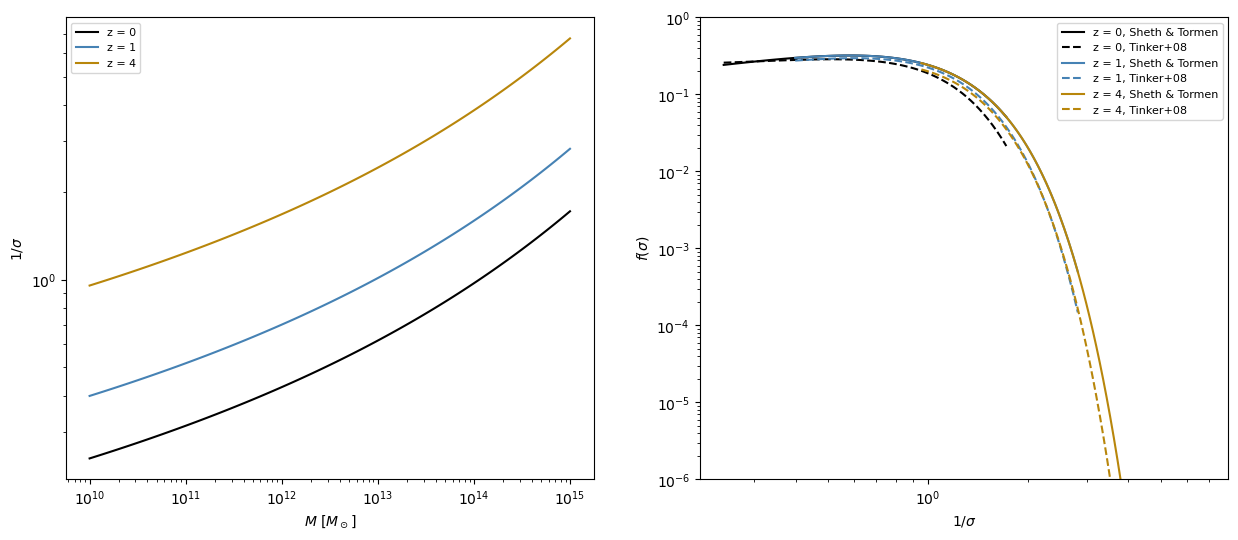

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for z, col in zip([0, 1, 4], ['black', 'steelblue', 'darkgoldenrod']):
    s = sigma_M(M_hmf, z, tng)
    fs = f_ST(s)
    Delta_z = 200 / (tng['Om'] * (1+z)**3 / E(z, tng['Om'], tng['Or'], tng['OL'])**2)
    axes[0].plot(M_hmf, 1 / s, color=col, label=f'z = {z}')
    axes[1].plot(1 / s, fs, color=col, label=f'z = {z}, Sheth & Tormen')
    axes[1].plot(1 / s, f_Tinker(s, z, Delta_z), color=col, ls='--', label=f'z = {z}, Tinker+08')
    print(f'z = {z}: 1/sigma from {1 / s.max():.2f} to {1 / s.min():.2f}')

axes[0].set(xscale='log', yscale='log', xlabel=r'$M$ [$M_\odot$]', ylabel=r'$1/\sigma$')
axes[1].set(xscale='log', yscale='log', xlabel=r'$1/\sigma$', ylabel=r'$f(\sigma)$', ylim=(1e-6, 1))
for ax in axes:
    ax.legend(fontsize=8)
plt.show()

### 3.2 discussion

The same mass range $10^{10-15}\,M_\odot$ maps to different ranges of $1/\sigma$: about 0.24–1.7 at z=0, 0.40–2.8 at z=1 and 0.96–6.8 at z=4, i.e. at high z the same haloes are much rarer peaks (higher $\nu = \delta_c/\sigma$). But in terms of $\sigma$ the Sheth & Tormen curves all lie on the same line, they only cover different parts of it: this is what universality means, all the redshift and cosmology dependence goes into $\sigma(M,z)$, and $f(\sigma)$ is one function. At z=4 we only see the exponential tail. Tinker+08 is not exactly universal: with its fitted (1+z) terms and the changing $\Delta$ the dashed curves are slightly shifted with z (at the 10–20% level), which is the level of non-universality they found in the simulations.

### 3.3 [Optional]

TNG300-3-Dark, M200c, at z = 0, 1, 4 (from 1.4). Each halo gets its $\sigma$ by interpolating the $\sigma(M,z)$-M relation of 2.4. From $\dfrac{dn}{dM} = f(\sigma)\dfrac{\bar\rho_m}{M}\dfrac{d\ln\sigma^{-1}}{dM}$ we get $dn = f(\sigma)\,\bar\rho_m\,d\ln\sigma^{-1}/M$, so in a bin of $\ln\sigma^{-1}$:

$f(\sigma) = \dfrac{\sum_{i\in \mathrm{bin}} M_i}{\bar\rho_m\,V\,\Delta\ln\sigma^{-1}}$

with $V$ the comoving volume and $\bar\rho_m$ the comoving mean density.

In [24]:
def f_sigma_sim(M, sig, volume, cosmo, bins):
    #f(sigma) measured from halo counts in log bins of 1/sigma
    #returns: bin centres in 1/sigma, f(sigma)
    mass_in_bin = np.histogram(1 / sig, bins=bins, weights=M)[0]
    f = mass_in_bin / (rho_mean(cosmo) * volume * np.diff(np.log(bins)))
    centres = np.sqrt(bins[1:] * bins[:-1])
    good = f > 0
    return centres[good], f[good]

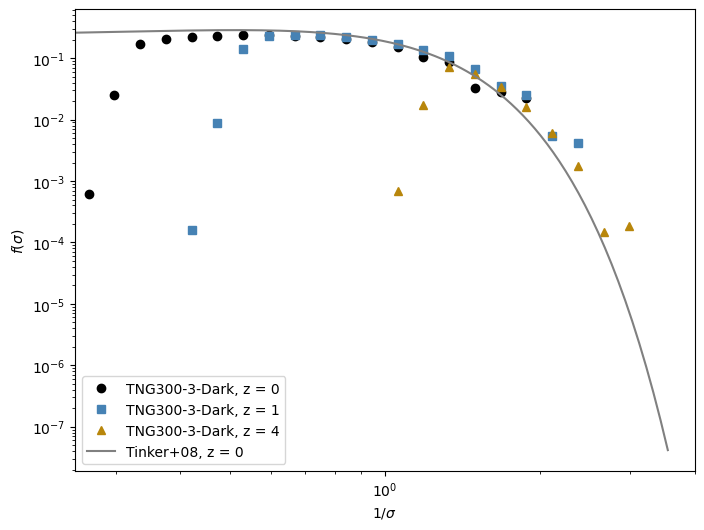

In [25]:
markers = {0: 'o', 1: 's', 4: '^'}
inv_sigma_bins = np.logspace(-0.6, 0.6, 25)

fig, ax = plt.subplots(figsize=(8, 6))
for z in [0, 1, 4]:
    masses_z, volume_z = mf_z[z]
    M = masses_z['M200c']
    sig = np.interp(np.log10(M), np.log10(M_grid), sigma_M(M_grid, z, tng))
    x, f_sim = f_sigma_sim(M, sig, volume_z, tng, inv_sigma_bins)
    ax.plot(x, f_sim, markers[z], color=z_colors[z], label=f'TNG300-3-Dark, z = {z}')

s = sigma_M(M_grid, 0, tng)
ax.plot(1 / s, f_Tinker(s, 0, Delta), color='gray', label='Tinker+08, z = 0')
ax.set(xscale='log', yscale='log', xlabel=r'$1/\sigma$', ylabel=r'$f(\sigma)$', xlim=(0.25, 4))
ax.legend()
plt.show()

### 3.3 discussion

The points from the three redshifts fall on the same curve within the scatter, close to the Tinker function, even though at fixed mass the halo abundance changes by orders of magnitude between z=0 and z=4 (1.4). So also in the simulation the mass function is (nearly) universal in $\sigma$. Each redshift covers a different range of $1/\sigma$: z=4 only reaches the high $1/\sigma$ part (rare peaks), z=0 the low part. The deviations are at the ends: at low $1/\sigma$ (small masses) the points drop because of the resolution limit of TNG300-3, at the highest $1/\sigma$ there are very few haloes per bin, so the points are noisy.

## 4. [Optional] The spatial distribution of dark-matter haloes

TNG300-3-Dark, M200c, comoving positions in Mpc. First the random catalogue: same number of haloes, positions uniform in $[0, L_{box}]$ for x, y, z.

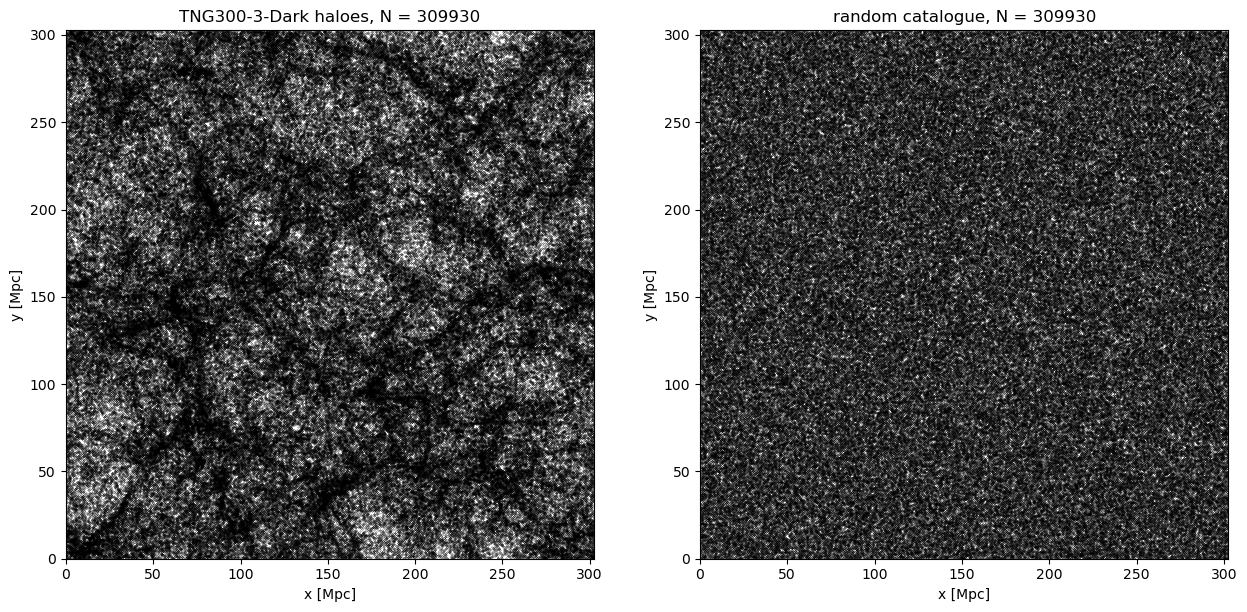

In [26]:
rng = np.random.default_rng(0)

def load_halo_pos(basePath, snap):
    #comoving positions [Mpc] and M200c [Msun], box size [Mpc]
    header = snap_header(basePath, snap)
    h = header['HubbleParam']
    halos = il.groupcat.loadHalos(basePath, snap, fields=['GroupPos', 'Group_M_Crit200'])
    return halos['GroupPos'] / h / 1000, halos['Group_M_Crit200'] * 1e10 / h, header['BoxSize'] / h / 1000

pos, M200c, box = load_halo_pos(sims['TNG300-3-Dark'], 99)
pos_rand = rng.uniform(0, box, size=pos.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, p, title in zip(axes, [pos, pos_rand], ['TNG300-3-Dark haloes', 'random catalogue']):
    ax.scatter(p[:, 0], p[:, 1], s=0.05, color='black')
    ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', xlim=(0, box), ylim=(0, box), title=f'{title}, N = {len(p)}')
    ax.set_aspect('equal')
plt.show()

The pair counts are done with `cKDTree.count_neighbors`, which gives the cumulative number of pairs within $r$ (with `boxsize` for the periodic box); the difference between two bin edges gives the pairs in the shell. The data and the random catalogue have the same number of haloes, so DD and DR are directly comparable and $\xi = DD/DR - 1$ (the self-pairs at $r=0$ cancel in the difference).

In [27]:
def xi_DD_DR(pos, pos_rand, box, r_bins):
    #xi(r) = DD/DR - 1 in the bins r_bins [Mpc], periodic box
    tree_D = cKDTree(pos % box, boxsize=box)
    tree_R = cKDTree(pos_rand % box, boxsize=box)
    DD = np.diff(tree_D.count_neighbors(tree_D, r_bins))
    DR = np.diff(tree_D.count_neighbors(tree_R, r_bins))
    return DD / DR - 1

z = 0, 3.2e+11 - 1.0e+12 Msun: N = 69223, xi(~5 Mpc) = 0.80
z = 0, 1.0e+12 - 3.2e+12 Msun: N = 25966, xi(~5 Mpc) = 1.03
z = 0, 3.2e+12 - 1.0e+13 Msun: N = 9408, xi(~5 Mpc) = 1.61


/tmp/ipykernel_4393/1996362654.py:7: RuntimeWarning: invalid value encountered in divide
  return DD / DR - 1


z = 0, 1.0e+13 - 1.0e+15 Msun: N = 4408, xi(~5 Mpc) = 2.84
z = 1, 3.2e+11 - 1.0e+12 Msun: N = 76710, xi(~5 Mpc) = 0.70
z = 1, 1.0e+12 - 3.2e+12 Msun: N = 26897, xi(~5 Mpc) = 1.04
z = 1, 3.2e+12 - 1.0e+13 Msun: N = 8180, xi(~5 Mpc) = 1.90
z = 1, 1.0e+13 - 1.0e+15 Msun: N = 2688, xi(~5 Mpc) = 5.03
z = 4, 3.2e+11 - 1.0e+12 Msun: N = 16742, xi(~5 Mpc) = 2.06
z = 4, 1.0e+12 - 3.2e+12 Msun: N = 2557, xi(~5 Mpc) = 4.97
z = 4, 3.2e+12 - 1.0e+13 Msun: N = 205, xi(~5 Mpc) = inf


/tmp/ipykernel_4393/1996362654.py:7: RuntimeWarning: divide by zero encountered in divide
  return DD / DR - 1


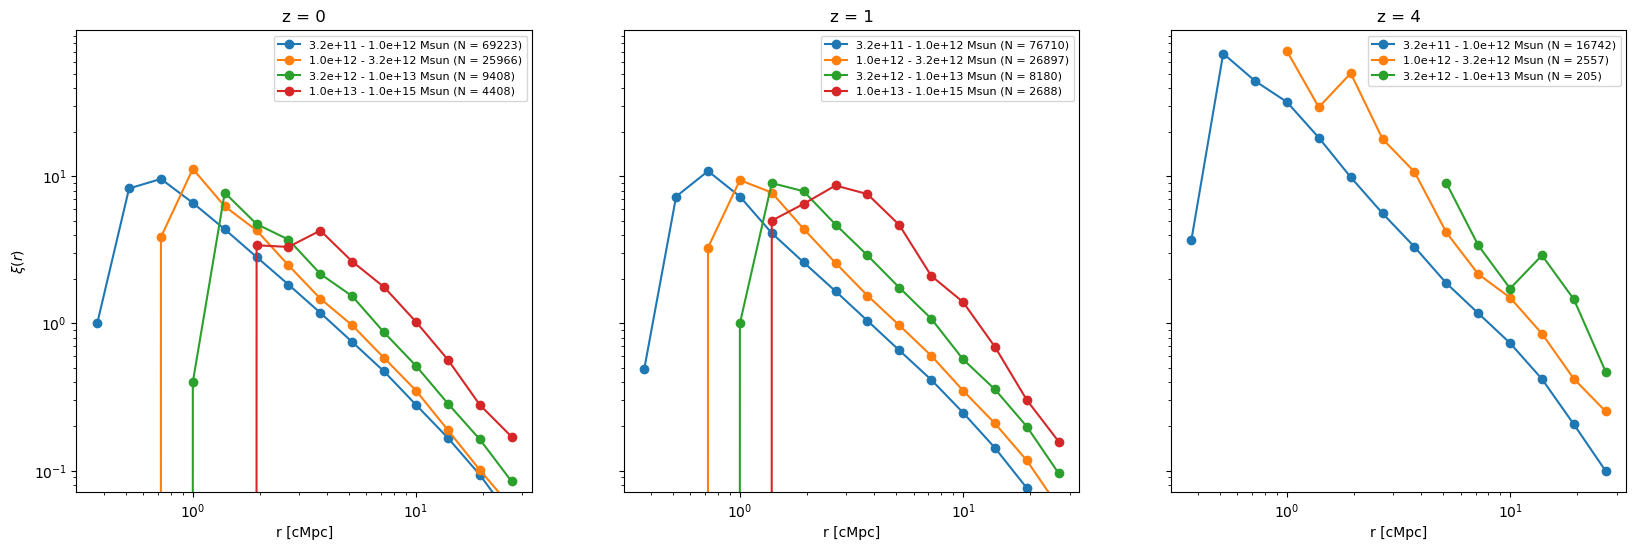

In [28]:
mass_bins = [10**11.5, 1e12, 10**12.5, 1e13, 1e15]   # Msun, manually set
r_bins = np.logspace(-0.5, 1.5, 15)                   # Mpc
r_mid = np.sqrt(r_bins[1:] * r_bins[:-1])

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, z in zip(axes, [0, 1, 4]):
    pos, M200c, box = load_halo_pos(sims['TNG300-3-Dark'], snaps_14[z])
    for low, high in zip(mass_bins[:-1], mass_bins[1:]):
        select = (M200c >= low) & (M200c < high)
        if select.sum() < 10:
            continue
        pos_rand = rng.uniform(0, box, size=pos[select].shape)
        xi = xi_DD_DR(pos[select], pos_rand, box, r_bins)
        ax.plot(r_mid, xi, marker='o', label=f'{low:.1e} - {high:.1e} Msun (N = {select.sum()})')
        print(f'z = {z}, {low:.1e} - {high:.1e} Msun: N = {select.sum()}, xi(~5 Mpc) = {np.interp(5, r_mid, xi):.2f}')
    ax.set(xscale='log', yscale='log', xlabel='r [cMpc]', title=f'z = {z}')
    ax.legend(fontsize=8)
axes[0].set_ylabel(r'$\xi(r)$')
plt.show()

### 4 discussion

The random catalogue looks uniform, while the real haloes trace the filaments and nodes of the cosmic web, so the procedure works. At fixed halo mass $\xi(r)$ decreases with separation, roughly as a power law ($\xi \propto r^{-\gamma}$ with $\gamma \sim 1.5$–2): haloes are strongly clustered on small scales (a few Mpc) and the distribution gets close to uniform ($\xi \ll 1$) on tens of Mpc. At the smallest separations (below ~2x the halo radius) the curves bend down or are empty, because two haloes cannot overlap (halo exclusion) and there are few pairs.

More massive haloes are more clustered: the $\xi(r)$ amplitude grows with the mass bin, the most massive bin being the most clustered. This is the halo bias, massive haloes form from the rare high peaks of the density field, which are themselves preferentially located in overdense large-scale regions. It is the same as what I saw by eye in Ex 1.1 of Problem Sheet 1, where the massive haloes sit in the nodes of the filaments and the mass cuts look more clustered. At fixed mass the clustering is stronger at higher z, because the same mass is a rarer peak at high z (see 2.4 and 3.2), so the bias is larger; at z=4 only the lower mass bins have enough haloes.